
**Lorenz–96 model and green function computation for two variables**

We consider the Lorenz–96 dynamical system for x and $\theta$:
$$
    dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - \alpha \theta_i - \gamma x_i + F
$$
$$
    d\theta_i/dt = x_{i+1} * \theta_{i+2} - x_{i-1} * \theta_{i-2} +\alpha x_i - \gamma \theta_i + G
$$
with cyclic indices:
$$
x_{i-N} = x_{i+N} = x_i 
$$
$$
\theta_{i-N} = \theta_{i+N} = \theta_i
$$

Parameters:
-  N : number of variables (typically 40)
-  F, G : constant forcing (typically F = 8 for chaotic regime)
-  $\alpha, \gamma$: perturbation

Considering $\gamma = \alpha = 1$, the **unperturbed system** is written as:
$$
\dot{x}_i = F_i(x)
$$
$$
\dot{\theta}_i = G_i(\theta)
$$

For Lorenz–96:

$$
F_i(x) = (x_{i+1} - x_{i-2}) * x_{i-1} - \theta_i - x_i + F
$$
$$
G_i(\theta) =  x_{i+1} * \theta_{i+2} - x_{i-1} * \theta_{i-2} + x_i - \theta_i + G
$$
The **perturbed system** is written as:
- Adding perturbation to F:
    $$
    \dot{x}_i = F_i(x) + \epsilon X_i(x) f(t)
    $$
   
- Adding perturbation to $\gamma$:
    $$
    \dot{x}_i = F_i(x) - \epsilon \gamma X_i(x)
    $$
    $$
    \dot{\theta}_i = G_i(x) - \epsilon \gamma \theta_i(x)
    $$
- Adding perturbation to $\alpha$:
    $$
    \dot{x}_i = F_i(x) - \epsilon \alpha \theta_i(x)
    $$
    $$
    \dot{\theta}_i = G_i(x) + \epsilon \alpha X_i(x)
    $$

Note: In the followwing cells, we have replaced $\theta$ with z due to the use of simpler notation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Lorenz-96 UNPERTURBED dynamics
def lorenz96(t, state, F, G):
    
    N = len(state) // 2

    x = state[:N]
    z = state[N:]

    dxdt = np.zeros(N)
    dzdt = np.zeros(N)

    
    for i in range(N):
        dxdt[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] - z[i] + F
        dzdt[i] = x[(i+1)%N] * z[(i+2)%N] - x[(i-1)%N] * z[(i-2)%N] +x[i] - z[i] + G
    
    return np.concatenate([dxdt, dzdt])
    
# Setting the initial conditions
def standard_initial_condition(F,G,N):
    x = F * np.ones(N)
    z = G * np.ones(N)
    x[0] += 0.01  # small perturbation
    z[0] += 0.01
    return x,z

In [3]:
#Parameters:
dt = 0.005; 
T = 10000 ; 
N = 40 ; 
F = 8;
G = 8;
t_span = (0, T)
t_eval = np.arange(0, T, dt)
x0, z0 = standard_initial_condition(F, G, N)
state0 = np.concatenate([x0, z0])

In [4]:
#Running unperturbed trajectory
solution = solve_ivp(
    fun=lambda t, state: lorenz96(t, state, F, G),
    t_span=t_span,
    y0=state0,    
    t_eval=t_eval,
    method='RK45'
)

traj = solution.y.T   # shape: (time, N)
time = solution.t

x_traj = traj[:, :N]
z_traj = traj[:, N:]

print(x_traj.shape)
print(z_traj.shape)

(2000000, 40)
(2000000, 40)


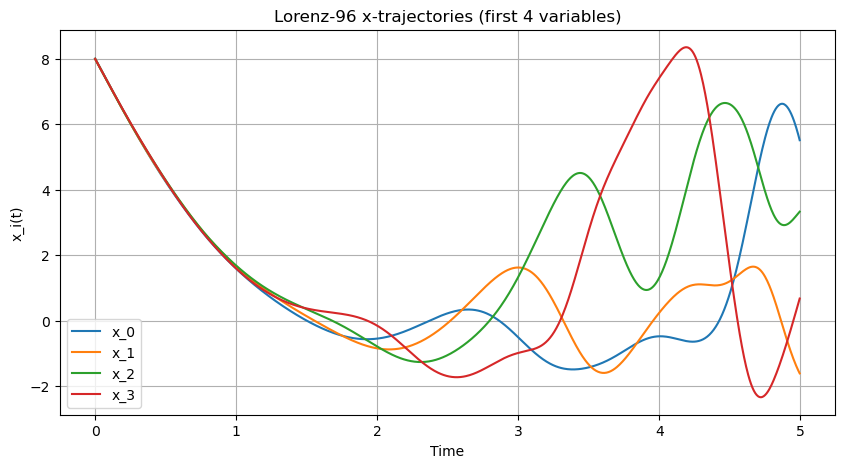

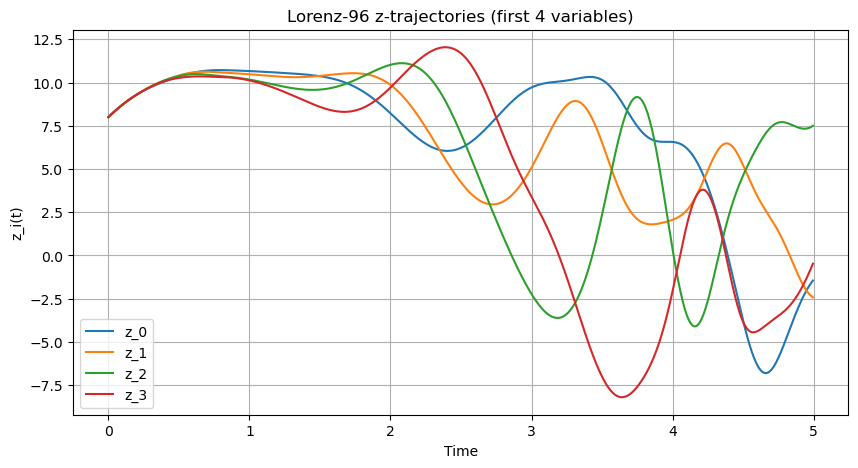

In [5]:
plt.figure(figsize=(10,5))

# plot the trajectories for first 4 variables
tau_plot = 1000
for i in range(4):
    plt.plot(time[:tau_plot], traj[:tau_plot, i], label=f"x_{i}")

plt.xlabel("Time")
plt.ylabel("x_i(t)")
plt.title("Lorenz-96 x-trajectories (first 4 variables)")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(10,5))

tau_plot = 1000

# Plot first 4 z variables
for i in range(4):
    plt.plot(time[:tau_plot], z_traj[:tau_plot, i], label=f"z_{i}")

plt.xlabel("Time")
plt.ylabel("z_i(t)")
plt.title("Lorenz-96 z-trajectories (first 4 variables)")
plt.legend()
plt.grid()

plt.show()

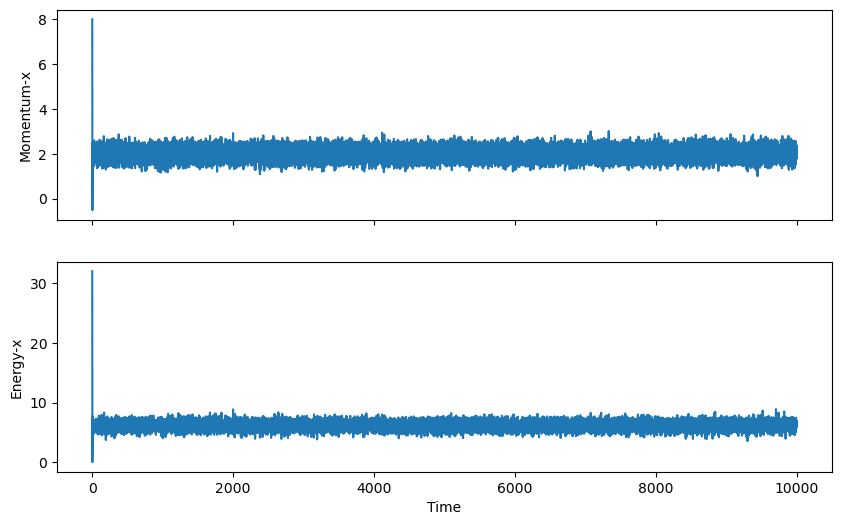

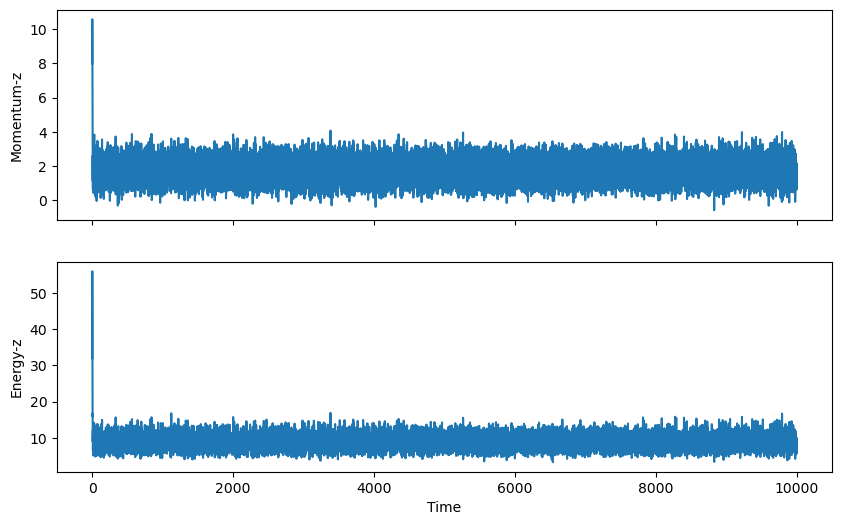

In [6]:
# Global observables for x variables
momentum_x = x_traj.mean(axis=1)
energy_x = 0.5 * (x_traj**2).mean(axis=1)

momentum_z = z_traj.mean(axis=1)
energy_z = 0.5 * (z_traj**2).mean(axis=1)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10,6))

ax[0].plot(time, momentum_x)
ax[0].set_ylabel("Momentum-x")

ax[1].plot(time, energy_x)
ax[1].set_ylabel("Energy-x")
ax[1].set_xlabel("Time")

plt.show()

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10,6))

ax[0].plot(time, momentum_z)
ax[0].set_ylabel("Momentum-z")

ax[1].plot(time, energy_z)
ax[1].set_ylabel("Energy-z")
ax[1].set_xlabel("Time")

plt.show()


Text(0, 0.5, 'Energy-z')

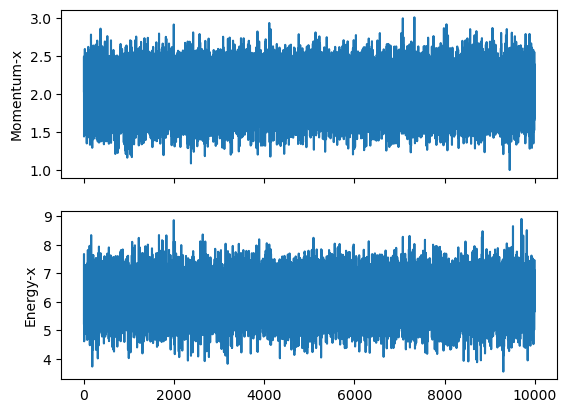

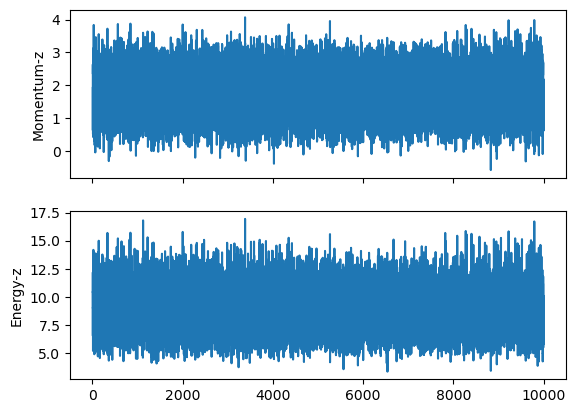

In [7]:
### Select the system when it has relaxed to the attractor (stationary state)
transient = 8
indx = np.where(time > transient)[0][0]

asymp_time = time[indx:]
asymp_traj_x = x_traj[indx:,:]
asymp_traj_z = z_traj[indx:,:]

# Global observables
asymp_momentum_x = asymp_traj_x.mean(axis=1)
asymp_momentum_z = asymp_traj_z.mean(axis=1)

asymp_energy_x = 0.5 *(asymp_traj_x**2).mean(axis=1)
asymp_energy_z = 0.5 *(asymp_traj_z**2).mean(axis=1)

fig , ax = plt.subplots(nrows=2,sharex=True)
ax[0].plot(asymp_time,asymp_momentum_x)
ax[0].set_ylabel("Momentum-x")

ax[1].plot(asymp_time,asymp_energy_x)
ax[1].set_ylabel("Energy-x")

fig , ax = plt.subplots(nrows=2,sharex=True)
ax[0].plot(asymp_time,asymp_momentum_z)
ax[0].set_ylabel("Momentum-z")

ax[1].plot(asymp_time,asymp_energy_z)
ax[1].set_ylabel("Energy-z")


In [8]:
### Correlation function analysis
# 1. The system has to be on the attractor (asymptotic state)
def autocorrelation(phi):
    # Gets the normalised correlation function
    phi = phi - np.mean(phi)
    N = len(phi)
    
    corr = np.correlate(phi, phi, mode='full')
    corr = corr[N-1:]
    
    return corr / corr[0]

corr_momentum_x = autocorrelation(asymp_momentum_x)
corr_momentum_z = autocorrelation(asymp_momentum_z)

corr_energy_x = autocorrelation(asymp_energy_x)
corr_energy_z = autocorrelation(asymp_energy_z)


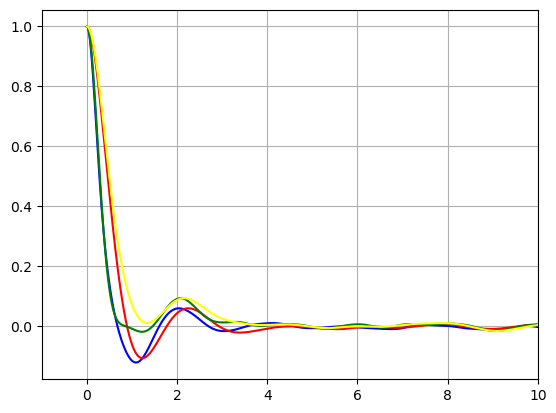

In [9]:
fig, ax = plt.subplots()
lags = np.arange(len(corr_momentum_x)) * dt
lags = np.arange(len(corr_momentum_z)) * dt

ax.plot(lags[:5000],corr_momentum_x[:5000], color = 'blue')
ax.plot(lags[:5000],corr_energy_x[:5000], color = 'red')
ax.plot(lags[:5000],corr_momentum_z[:5000], color = 'green')
ax.plot(lags[:5000],corr_energy_z[:5000], color = 'yellow')
ax.set_xlim(left=-1,right=10)
ax.grid()

### Response Properties:
1. Sample unperturbed states **&#10003;Done**
2. Use those as initial conditions for your response experiments **&#10003;Done**

In [10]:
# Figuring out the initial conditions: states of the system separated at least by one correlation timescale
correlation_timescale = 2
correlation_timescale_index = int( correlation_timescale / dt )

unperturbed_sample_x = asymp_traj_x[::correlation_timescale_index,:]
unperturbed_sample_z = asymp_traj_z[::correlation_timescale_index,:]

We have found the unperturbed $ \{ (x_i, z_i)\}_{i=1}^M $. Now let's proceed with the perturbation:

- Fix $x_1$, perturb

$\hat{x}_1 = x_1 + \varepsilon X(x_1)$

For example, change in F, this corresponds to X(x) = (1,1, .., 1,0,0,...,0)

Given $\hat{x}_1$, we use it as initial condition for an **unperturbed** run.

In [11]:
#Condireing all variables and three values for perturbation
#Perturbation in F:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []

eps1 = 0.2
eps2 = 0.5
eps3 = 0.8

for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi + eps1
    xi_hat2 = xi + eps2
    xi_hat3 = xi + eps3
    
    zi = unperturbed_sample_z[i, :]
    zi_hat = zi  

    state_hat1 = np.concatenate([xi_hat1, zi_hat])
    state_hat2 = np.concatenate([xi_hat2, zi_hat])
    state_hat3 = np.concatenate([xi_hat3, zi_hat])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_x = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_x = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_x = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_z = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_z = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_z = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


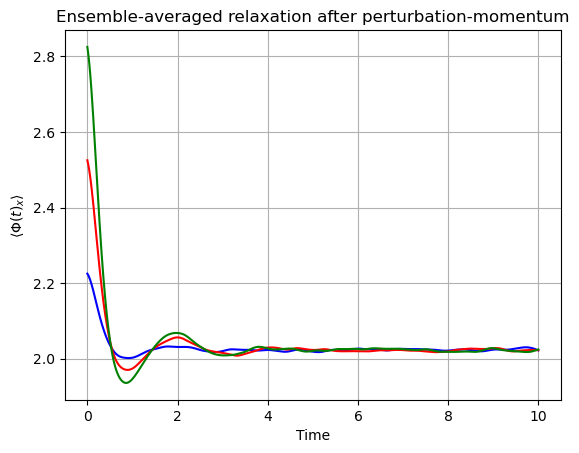

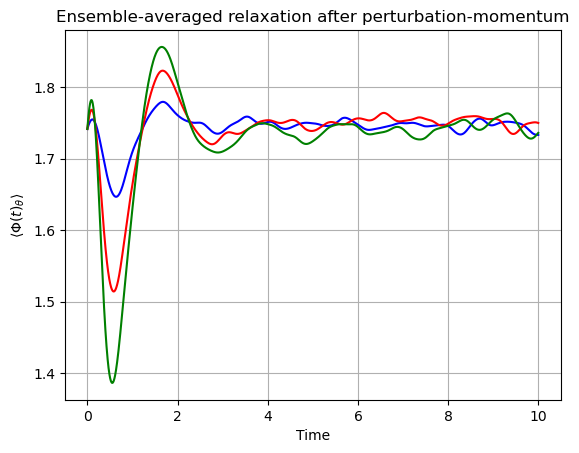

In [21]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_x, color='blue')
ax.plot(time_relax, mean_response_2_x, color='red')
ax.plot(time_relax, mean_response_3_x, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_z, color='blue')
ax.plot(time_relax, mean_response_2_z, color='red')
ax.plot(time_relax, mean_response_3_z, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


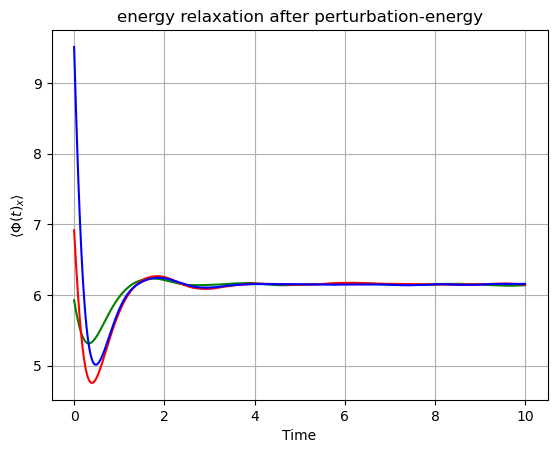

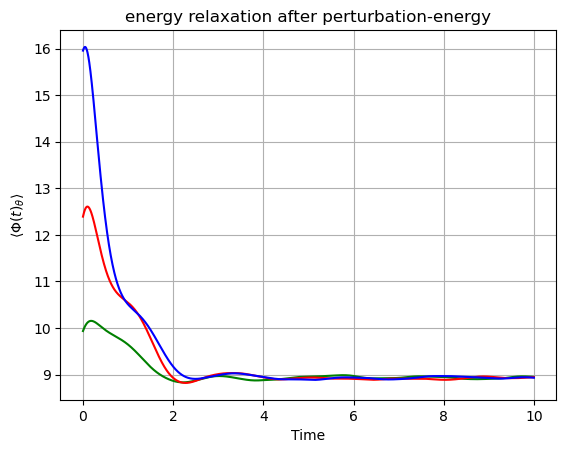

In [22]:
mean_energy_response_1_x = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_x = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_x = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_z = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_z = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_z = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_x, color='green')
ax.plot(time_relax, mean_energy_response_2_x, color='red')
ax.plot(time_relax, mean_energy_response_3_x, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_z, color='green')
ax.plot(time_relax, mean_energy_response_2_z, color='red')
ax.plot(time_relax, mean_energy_response_3_z, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


In [14]:
#Condireing all variables and three values for perturbation
#Perturbation in gamma:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []

eps1 = 0.2
eps2 = 0.5
eps3 = 0.8

for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi - eps1 * xi
    xi_hat2 = xi - eps2 * xi
    xi_hat3 = xi - eps3 * xi
    
    zi = unperturbed_sample_z[i, :]
    zi_hat1 = zi - eps1 * zi
    zi_hat2 = zi - eps2 * zi
    zi_hat3 = zi - eps3 * zi

    state_hat1 = np.concatenate([xi_hat1, zi_hat1])
    state_hat2 = np.concatenate([xi_hat2, zi_hat2])
    state_hat3 = np.concatenate([xi_hat3, zi_hat3])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_xg = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_xg = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_xg = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_zg = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_zg = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_zg = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


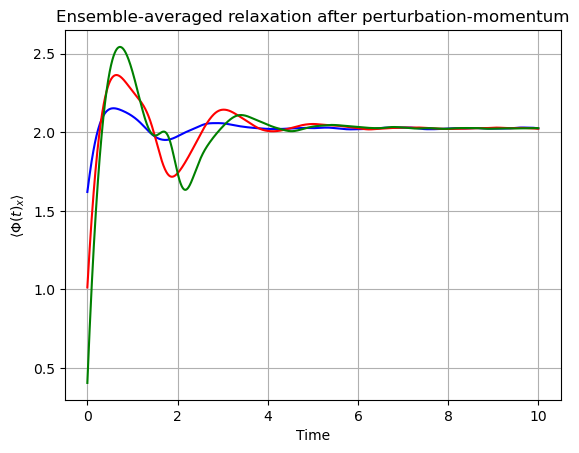

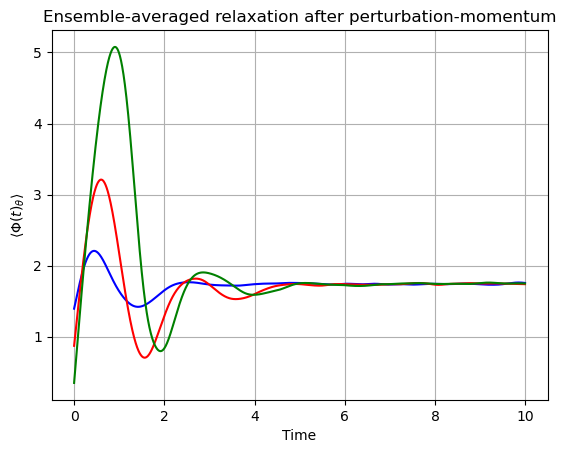

In [23]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_xg, color='blue')
ax.plot(time_relax, mean_response_2_xg, color='red')
ax.plot(time_relax, mean_response_3_xg, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_zg, color='blue')
ax.plot(time_relax, mean_response_2_zg, color='red')
ax.plot(time_relax, mean_response_3_zg, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


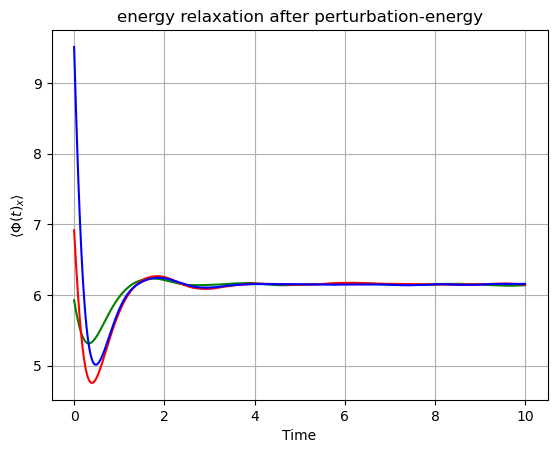

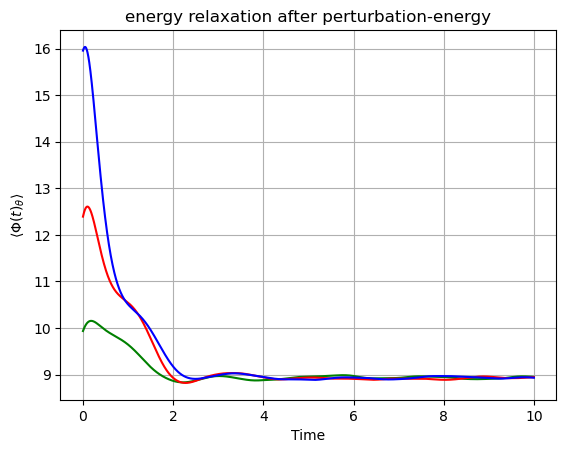

In [24]:
mean_energy_response_1_xg = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_xg = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_xg = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_zg = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_zg = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_zg = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_xg, color='green')
ax.plot(time_relax, mean_energy_response_2_xg, color='red')
ax.plot(time_relax, mean_energy_response_3_xg, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_zg, color='green')
ax.plot(time_relax, mean_energy_response_2_zg, color='red')
ax.plot(time_relax, mean_energy_response_3_zg, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


In [18]:
#Condireing all variables and three values for perturbation
#Perturbation in alpha:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []

eps1 = 0.2
eps2 = 0.5
eps3 = 0.8

for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi - eps1 * zi
    xi_hat2 = xi - eps2 * zi
    xi_hat3 = xi - eps3 * zi
    
    zi = unperturbed_sample_z[i, :]
    zi_hat1 = zi + eps1 * xi
    zi_hat2 = zi + eps2 * xi
    zi_hat3 = zi + eps3 * xi

    state_hat1 = np.concatenate([xi_hat1, zi_hat1])
    state_hat2 = np.concatenate([xi_hat2, zi_hat2])
    state_hat3 = np.concatenate([xi_hat3, zi_hat3])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_xa = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_xa = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_xa = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_za = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_za = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_za = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


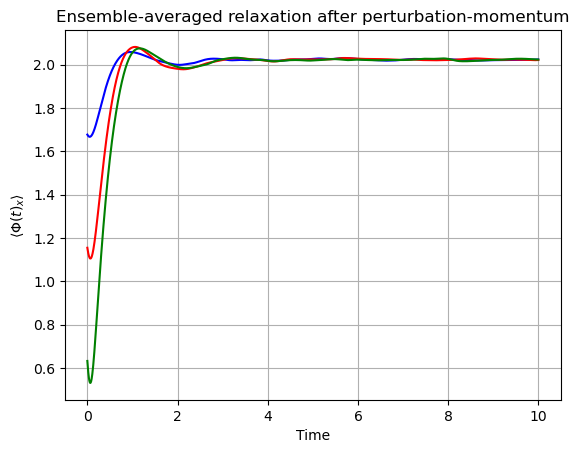

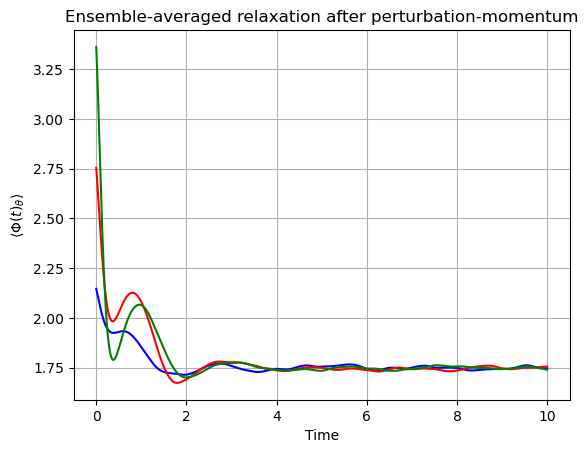

In [25]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_xa, color='blue')
ax.plot(time_relax, mean_response_2_xa, color='red')
ax.plot(time_relax, mean_response_3_xa, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_za, color='blue')
ax.plot(time_relax, mean_response_2_za, color='red')
ax.plot(time_relax, mean_response_3_za, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta\rangle$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


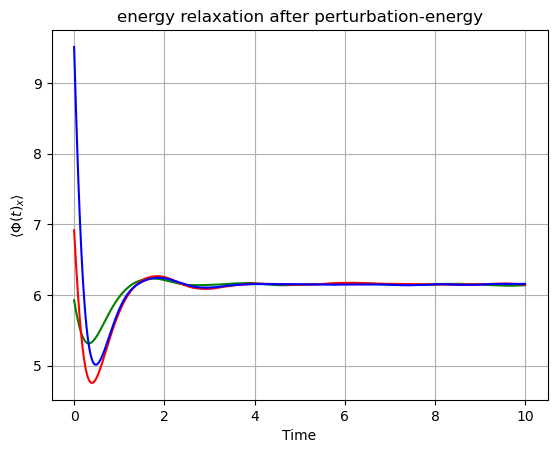

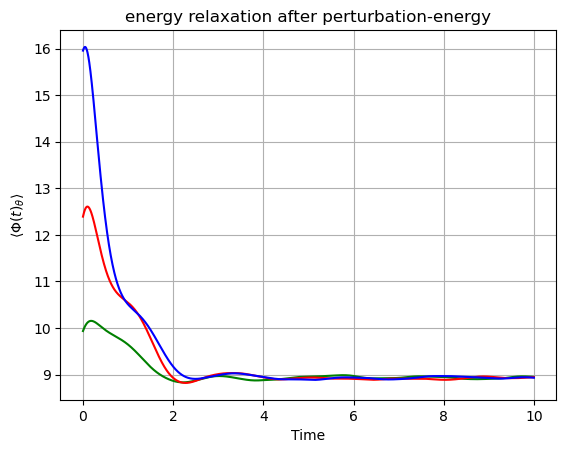

In [26]:
mean_energy_response_1_xa = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_xa = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_xa = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_za = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_za = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_za = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_xa, color='green')
ax.plot(time_relax, mean_energy_response_2_xa, color='red')
ax.plot(time_relax, mean_energy_response_3_xa, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_za, color='green')
ax.plot(time_relax, mean_energy_response_2_za, color='red')
ax.plot(time_relax, mean_energy_response_3_za, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


## Now, we work on $-\epsilon$ to find $\langle\psi\rangle_{-\epsilon}$:

In [27]:
#Considering all variables and three values for perturbation
#Perturbation in F:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []

for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi - eps1
    xi_hat2 = xi - eps2
    xi_hat3 = xi - eps3
    
    zi = unperturbed_sample_z[i, :]
    zi_hat = zi  

    state_hat1 = np.concatenate([xi_hat1, zi_hat])
    state_hat2 = np.concatenate([xi_hat2, zi_hat])
    state_hat3 = np.concatenate([xi_hat3, zi_hat])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_xm = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_xm = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_xm = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_zm = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_zm = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_zm = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


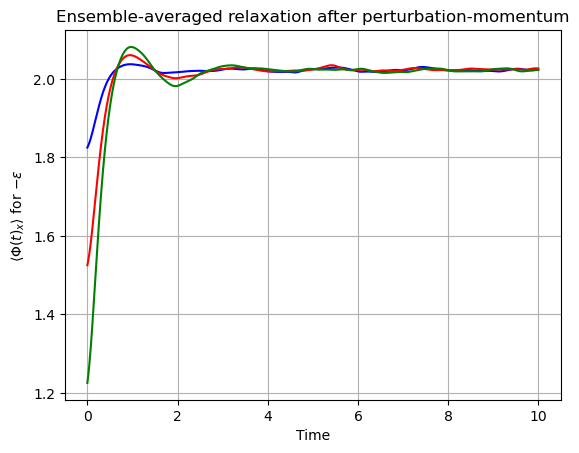

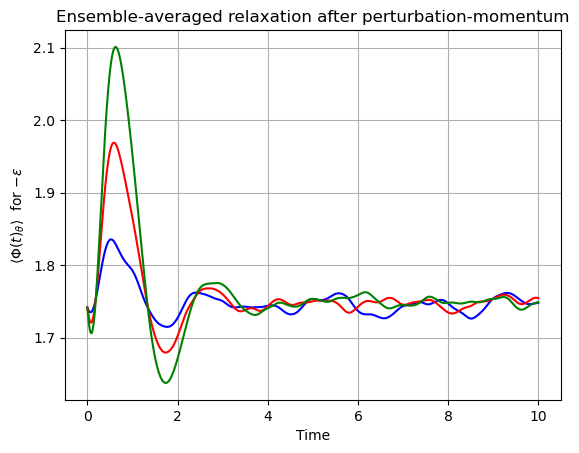

In [28]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_xm, color='blue')
ax.plot(time_relax, mean_response_2_xm, color='red')
ax.plot(time_relax, mean_response_3_xm, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_zm, color='blue')
ax.plot(time_relax, mean_response_2_zm, color='red')
ax.plot(time_relax, mean_response_3_zm, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$  for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


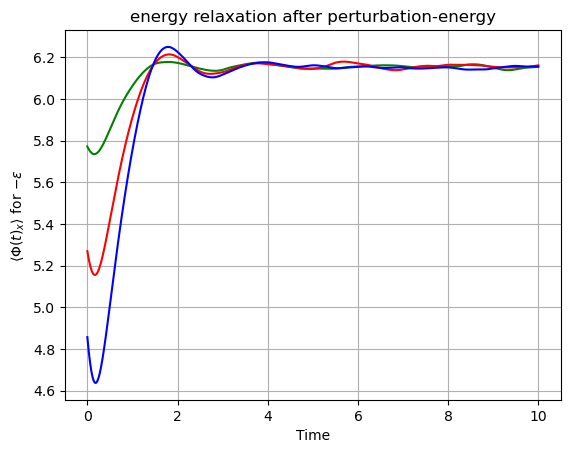

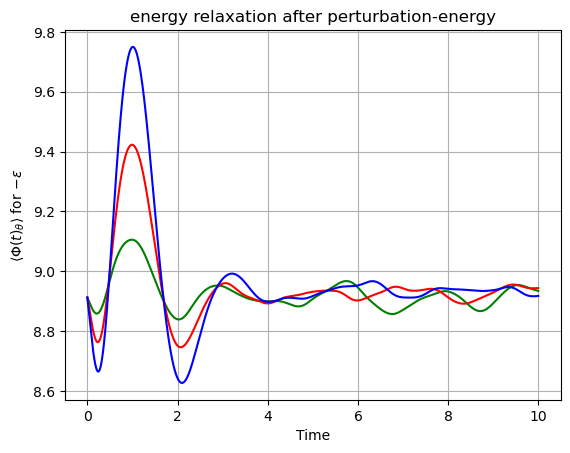

In [29]:
mean_energy_response_1_xm = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_xm = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_xm = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_zm = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_zm = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_zm = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_xm, color='green')
ax.plot(time_relax, mean_energy_response_2_xm, color='red')
ax.plot(time_relax, mean_energy_response_3_xm, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_zm, color='green')
ax.plot(time_relax, mean_energy_response_2_zm, color='red')
ax.plot(time_relax, mean_energy_response_3_zm, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


In [30]:
#Condireing all variables and three values for perturbation
#Perturbation in gamma:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []

for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi + eps1 * xi
    xi_hat2 = xi + eps2 * xi
    xi_hat3 = xi + eps3 * xi
    
    zi = unperturbed_sample_z[i, :]
    zi_hat1 = zi + eps1 * zi
    zi_hat2 = zi + eps2 * zi
    zi_hat3 = zi + eps3 * zi

    state_hat1 = np.concatenate([xi_hat1, zi_hat1])
    state_hat2 = np.concatenate([xi_hat2, zi_hat2])
    state_hat3 = np.concatenate([xi_hat3, zi_hat3])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_xgm = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_xgm = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_xgm = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_zgm = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_zgm = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_zgm = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


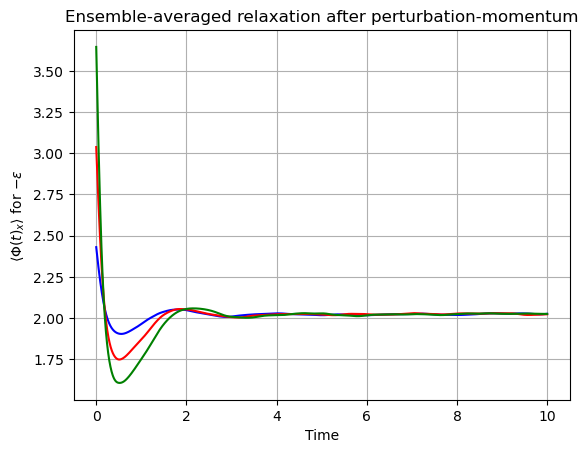

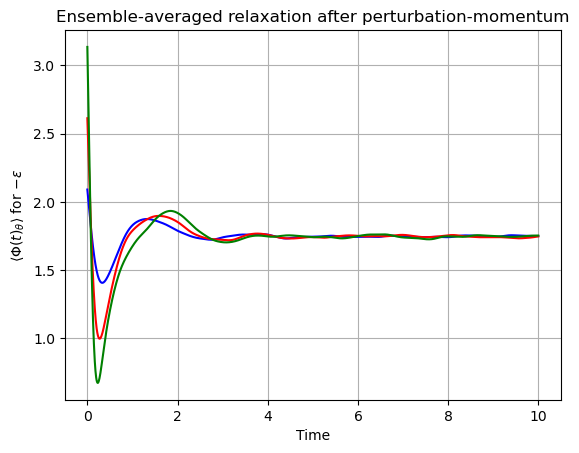

In [31]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_xgm, color='blue')
ax.plot(time_relax, mean_response_2_xgm, color='red')
ax.plot(time_relax, mean_response_3_xgm, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_zgm, color='blue')
ax.plot(time_relax, mean_response_2_zgm, color='red')
ax.plot(time_relax, mean_response_3_zgm, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$ for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


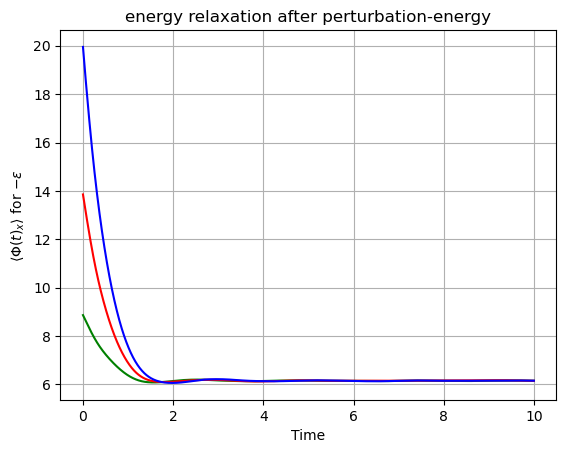

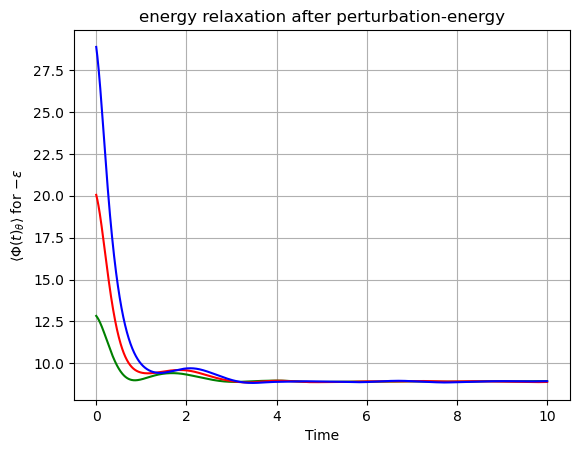

In [32]:
mean_energy_response_1_xgm = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_xgm = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_xgm = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_zgm = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_zgm = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_zgm = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_xgm, color='green')
ax.plot(time_relax, mean_energy_response_2_xgm, color='red')
ax.plot(time_relax, mean_energy_response_3_xgm, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_zgm, color='green')
ax.plot(time_relax, mean_energy_response_2_zgm, color='red')
ax.plot(time_relax, mean_energy_response_3_zgm, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


In [33]:
#Condireing all variables and three values for perturbation
#Perturbation in alpha:

print("Number of samples x:", len(unperturbed_sample_x))
print("Number of samples z:", len(unperturbed_sample_z))


M = len(unperturbed_sample_x)

relaxation1_momentum_list_x = []
relaxation2_momentum_list_x = []
relaxation3_momentum_list_x = []

relaxation1_momentum_list_z = []
relaxation2_momentum_list_z = []
relaxation3_momentum_list_z = []

relaxation1_energy_list_x = []
relaxation2_energy_list_x = []
relaxation3_energy_list_x = []


relaxation1_energy_list_z = []
relaxation2_energy_list_z = []
relaxation3_energy_list_z = []


for i in range(M):
    xi = unperturbed_sample_x[i, :]
    xi_hat1 = xi + eps1 * zi
    xi_hat2 = xi + eps2 * zi
    xi_hat3 = xi + eps3 * zi
    
    zi = unperturbed_sample_z[i, :]
    zi_hat1 = zi - eps1 * xi
    zi_hat2 = zi - eps2 * xi
    zi_hat3 = zi - eps3 * xi

    state_hat1 = np.concatenate([xi_hat1, zi_hat1])
    state_hat2 = np.concatenate([xi_hat2, zi_hat2])
    state_hat3 = np.concatenate([xi_hat3, zi_hat3])
    
    solution1 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat1,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution2 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat2,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    solution3 = solve_ivp(
        fun=lambda t, state: lorenz96(t, state, F, G),
        t_span=(0, 10),
        y0=state_hat3,
        t_eval=np.arange(0, 10, dt),
        method='RK45'
    )
    trajectory1 = solution1.y.T
    trajectory2 = solution2.y.T
    trajectory3 = solution3.y.T

    traj1_x = trajectory1[:, :N]
    traj1_z = trajectory1[:, N:]

    traj2_x = trajectory2[:, :N]
    traj2_z = trajectory2[:, N:]

    traj3_x = trajectory3[:, :N]
    traj3_z = trajectory3[:, N:]

    relaxation_momentum_i1_x = traj1_x.mean(axis=1)
    relaxation_momentum_i2_x = traj2_x.mean(axis=1)
    relaxation_momentum_i3_x = traj3_x.mean(axis=1)

    relaxation_momentum_i1_z = traj1_z.mean(axis=1)
    relaxation_momentum_i2_z = traj2_z.mean(axis=1)
    relaxation_momentum_i3_z = traj3_z.mean(axis=1)

    relaxation_energy_i1_x = 0.5 * (traj1_x**2).mean(axis=1)
    relaxation_energy_i2_x = 0.5 * (traj2_x**2).mean(axis=1)
    relaxation_energy_i3_x = 0.5 * (traj3_x**2).mean(axis=1)

    relaxation_energy_i1_z = 0.5 * (traj1_z**2).mean(axis=1)
    relaxation_energy_i2_z = 0.5 * (traj2_z**2).mean(axis=1)
    relaxation_energy_i3_z = 0.5 * (traj3_z**2).mean(axis=1)

    relaxation1_momentum_list_x.append(relaxation_momentum_i1_x)
    relaxation2_momentum_list_x.append(relaxation_momentum_i2_x)
    relaxation3_momentum_list_x.append(relaxation_momentum_i3_x)

    relaxation1_momentum_list_z.append(relaxation_momentum_i1_z)
    relaxation2_momentum_list_z.append(relaxation_momentum_i2_z)
    relaxation3_momentum_list_z.append(relaxation_momentum_i3_z)

    relaxation1_energy_list_x.append(relaxation_energy_i1_x)
    relaxation2_energy_list_x.append(relaxation_energy_i2_x)
    relaxation3_energy_list_x.append(relaxation_energy_i3_x)

    relaxation1_energy_list_z.append(relaxation_energy_i1_z)
    relaxation2_energy_list_z.append(relaxation_energy_i2_z)
    relaxation3_energy_list_z.append(relaxation_energy_i3_z)

# plot
mean_response_1_xam = np.mean(relaxation1_momentum_list_x, axis=0)
mean_response_2_xam = np.mean(relaxation2_momentum_list_x, axis=0)
mean_response_3_xam = np.mean(relaxation3_momentum_list_x, axis=0)

mean_response_1_zam = np.mean(relaxation1_momentum_list_z, axis=0)
mean_response_2_zam = np.mean(relaxation2_momentum_list_z, axis=0)
mean_response_3_zam = np.mean(relaxation3_momentum_list_z, axis=0)


Number of samples x: 4996
Number of samples z: 4996


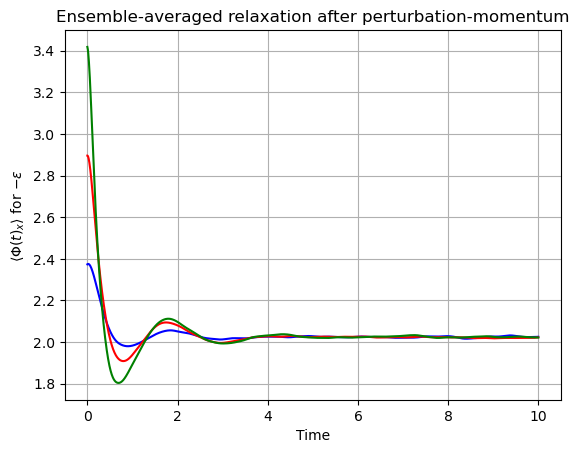

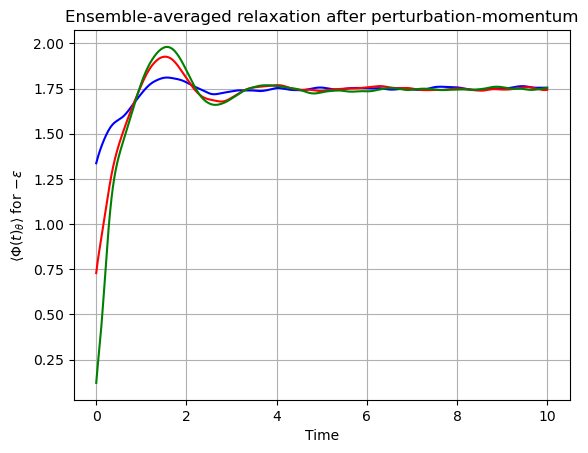

In [34]:
time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_xam, color='blue')
ax.plot(time_relax, mean_response_2_xam, color='red')
ax.plot(time_relax, mean_response_3_xam, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_response_1_zam, color='blue')
ax.plot(time_relax, mean_response_2_zam, color='red')
ax.plot(time_relax, mean_response_3_zam, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$ for $-\epsilon$")
ax.set_title("Ensemble-averaged relaxation after perturbation-momentum")

ax.grid()
plt.show()


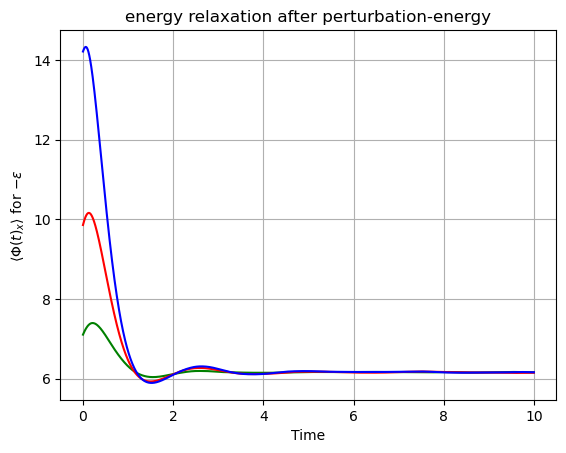

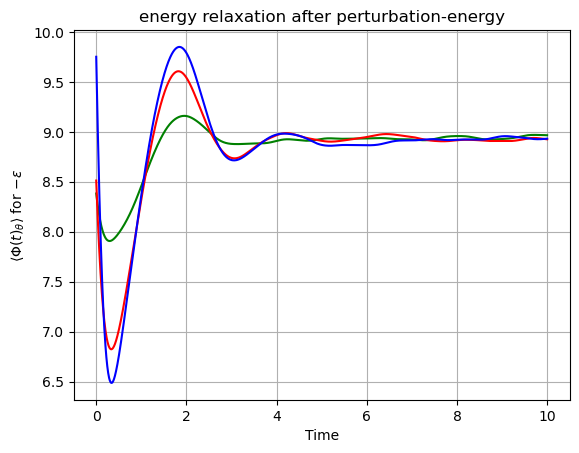

In [35]:
mean_energy_response_1_xam = np.mean(relaxation1_energy_list_x, axis=0)
mean_energy_response_2_xam = np.mean(relaxation2_energy_list_x, axis=0)
mean_energy_response_3_xam = np.mean(relaxation3_energy_list_x, axis=0)

mean_energy_response_1_zam = np.mean(relaxation1_energy_list_z, axis=0)
mean_energy_response_2_zam = np.mean(relaxation2_energy_list_z, axis=0)
mean_energy_response_3_zam = np.mean(relaxation3_energy_list_z, axis=0)

fig, ax = plt.subplots()
ax.plot(time_relax, mean_energy_response_1_xam, color='green')
ax.plot(time_relax, mean_energy_response_2_xam, color='red')
ax.plot(time_relax, mean_energy_response_3_xam, color='blue')
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_x \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, mean_energy_response_1_zam, color='green')
ax.plot(time_relax, mean_energy_response_2_zam, color='red')
ax.plot(time_relax, mean_energy_response_3_zam, color='blue')

ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle \Phi(t)_\theta \rangle$ for $-\epsilon$")
ax.set_title("energy relaxation after perturbation-energy")

ax.grid()
plt.show()


**Green function:**

Now, I try to find the green function for three different values as the different perturbations:

$$
G_x(t) = \frac{\langle\psi\rangle_{\epsilon x}-\langle\psi\rangle_{-\epsilon x}}{2\epsilon}
$$
$$
G_z(t) = \frac{\langle\psi\rangle_{\epsilon z}-\langle\psi\rangle_{-\epsilon z}}{2\epsilon}
$$

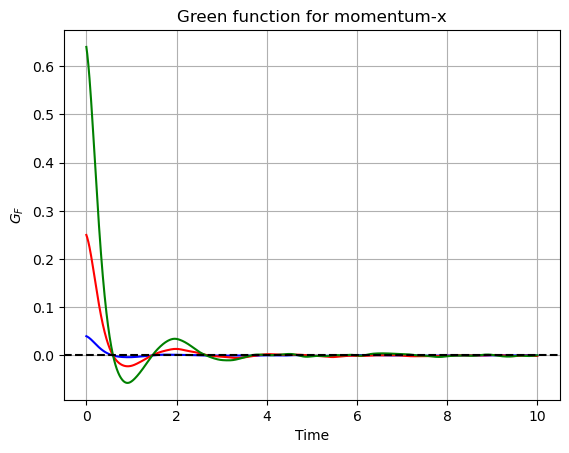

C:\Users\zenbook\anaconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


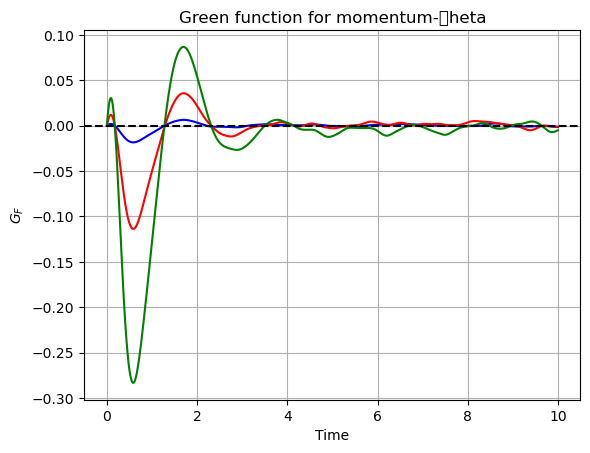

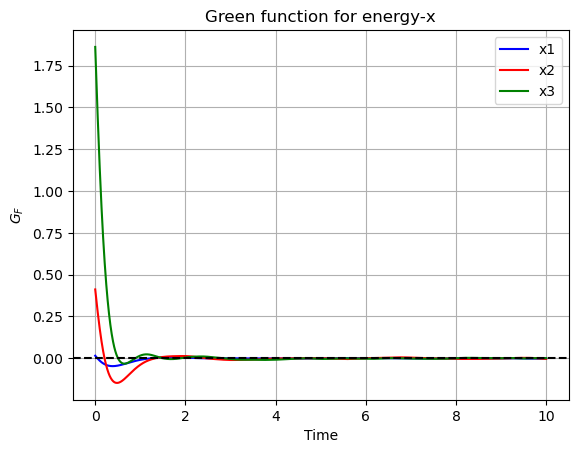

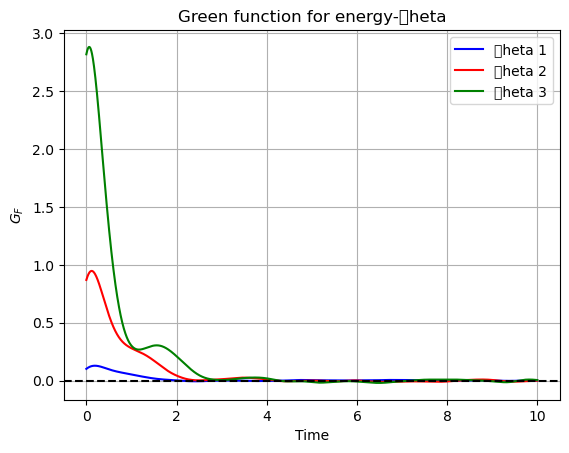

In [36]:
#Green function
# Considering the perturbation on F

G_mom_1x_F = (mean_response_1_x - mean_response_1_xm)/ 2 * eps1
G_mom_2x_F = (mean_response_2_x - mean_response_2_xm)/ 2 * eps2
G_mom_3x_F = (mean_response_3_x - mean_response_3_xm)/ 2 * eps3

G_mom_1z_F = (mean_response_1_z - mean_response_1_zm)/ 2 * eps1
G_mom_2z_F = (mean_response_2_z - mean_response_2_zm)/ 2 * eps2
G_mom_3z_F = (mean_response_3_z - mean_response_3_zm)/ 2 * eps3

G_energy_1x_F = (mean_energy_response_1_x - mean_energy_response_1_xm)/ 2 * eps1
G_energy_2x_F = (mean_energy_response_2_x - mean_energy_response_2_xm)/ 2 * eps2
G_energy_3x_F = (mean_energy_response_3_x - mean_energy_response_3_xm)/ 2 * eps3

G_energy_1z_F = (mean_energy_response_1_z - mean_energy_response_1_zm)/ 2 * eps1
G_energy_2z_F = (mean_energy_response_2_z - mean_energy_response_2_zm)/ 2 * eps2
G_energy_3z_F = (mean_energy_response_3_z - mean_energy_response_3_zm)/ 2 * eps3

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1x_F, color='blue')
ax.plot(time_relax, G_mom_2x_F, color='red')
ax.plot(time_relax, G_mom_3x_F, color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_F$")
ax.set_title("Green function for momentum-x")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1z_F, color='blue')
ax.plot(time_relax, G_mom_2z_F, color='red')
ax.plot(time_relax, G_mom_3z_F, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_F$")
ax.set_title("Green function for momentum-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1x_F, label='x1', color='blue')
ax.plot(time_relax, G_energy_2x_F, label='x2', color='red')
ax.plot(time_relax, G_energy_3x_F, label='x3', color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_F$")
ax.set_title("Green function for energy-x")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1z_F, label='$\\theta$ 1', color='blue')
ax.plot(time_relax, G_energy_2z_F, label='$\\theta$ 2', color='red')
ax.plot(time_relax, G_energy_3z_F, label='$\\theta$ 3', color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_F$")
ax.set_title("Green function for energy-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

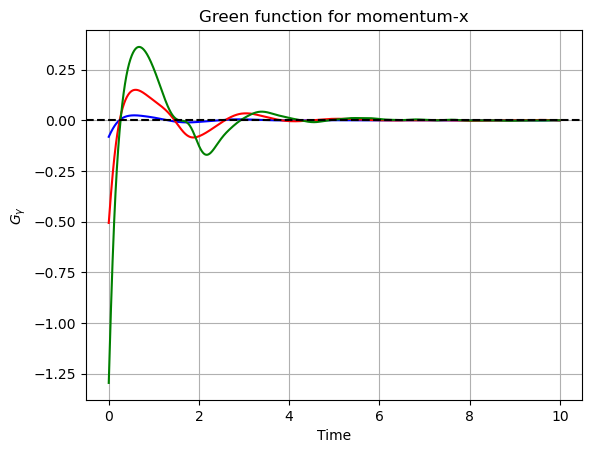

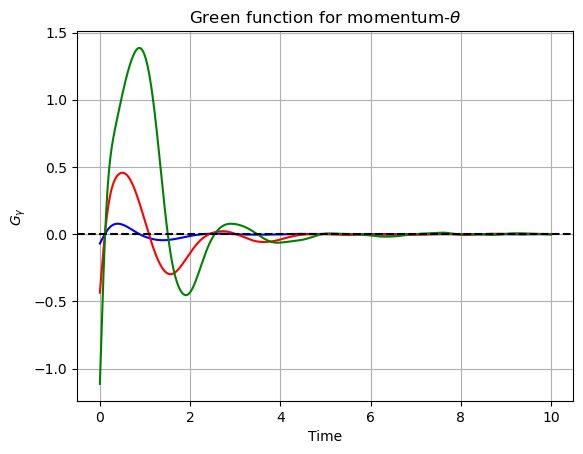

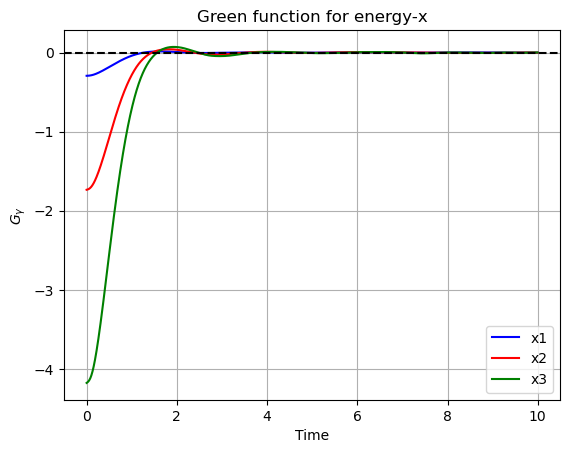

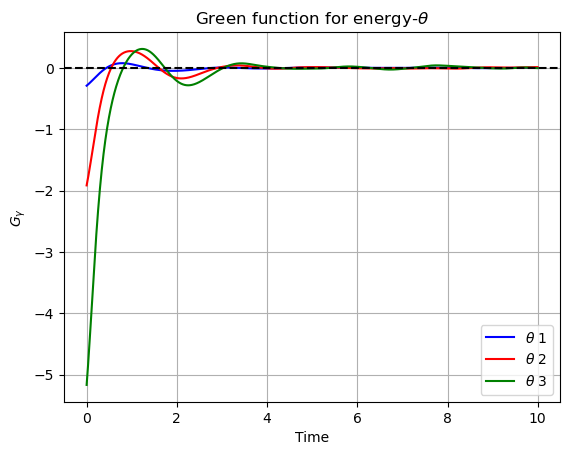

In [51]:
#Green function
# Considering the perturbation on gamma

G_mom_1x_g = (mean_response_1_xg - mean_response_1_xgm)/ 2 * eps1
G_mom_2x_g = (mean_response_2_xg - mean_response_2_xgm)/ 2 * eps2
G_mom_3x_g = (mean_response_3_xg - mean_response_3_xgm)/ 2 * eps3

G_mom_1z_g = (mean_response_1_zg - mean_response_1_zgm)/ 2 * eps1
G_mom_2z_g = (mean_response_2_zg - mean_response_2_zgm)/ 2 * eps2
G_mom_3z_g = (mean_response_3_zg - mean_response_3_zgm)/ 2 * eps3

G_energy_1x_g = (mean_energy_response_1_xg - mean_energy_response_1_xgm)/ 2 * eps1
G_energy_2x_g = (mean_energy_response_2_xg - mean_energy_response_2_xgm)/ 2 * eps2
G_energy_3x_g = (mean_energy_response_3_xg - mean_energy_response_3_xgm)/ 2 * eps3

G_energy_1z_g = (mean_energy_response_1_zg - mean_energy_response_1_zgm)/ 2 * eps1
G_energy_2z_g = (mean_energy_response_2_zg - mean_energy_response_2_zgm)/ 2 * eps2
G_energy_3z_g = (mean_energy_response_3_zg - mean_energy_response_3_zgm)/ 2 * eps3

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1x_g, color='blue')
ax.plot(time_relax, G_mom_2x_g, color='red')
ax.plot(time_relax, G_mom_3x_g, color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\gamma$")
ax.set_title("Green function for momentum-x")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1z_g, color='blue')
ax.plot(time_relax, G_mom_2z_g, color='red')
ax.plot(time_relax, G_mom_3z_g, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\gamma$")
ax.set_title("Green function for momentum-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1x_g, label='x1', color='blue')
ax.plot(time_relax, G_energy_2x_g, label='x2', color='red')
ax.plot(time_relax, G_energy_3x_g, label='x3', color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\gamma$")
ax.set_title("Green function for energy-x")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1z_g, label='$\\theta$ 1', color='blue')
ax.plot(time_relax, G_energy_2z_g, label='$\\theta$ 2', color='red')
ax.plot(time_relax, G_energy_3z_g, label='$\\theta$ 3', color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\gamma$")
ax.set_title("Green function for energy-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

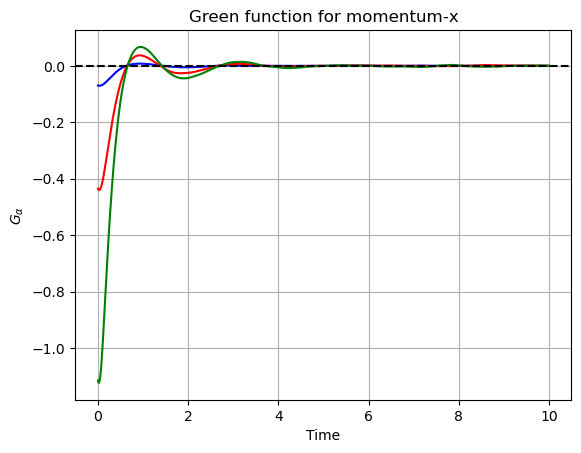

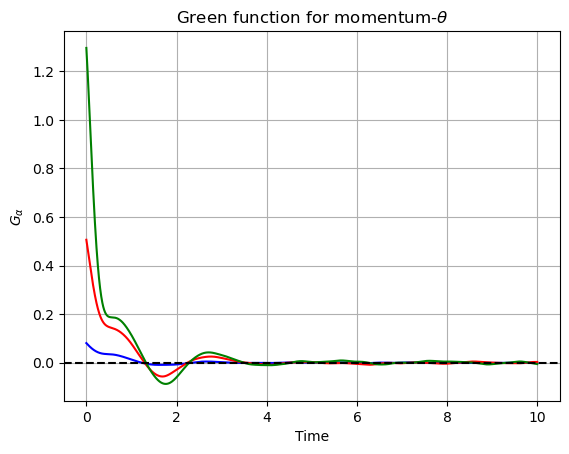

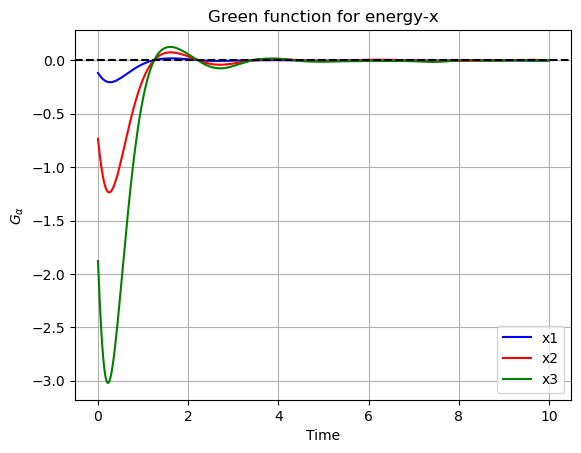

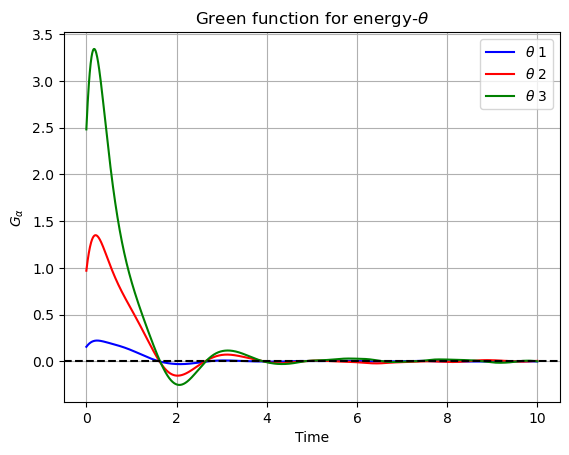

In [50]:
#Green function
# Considering the perturbation on alpha

G_mom_1x_a = (mean_response_1_xa - mean_response_1_xam)/ 2 * eps1
G_mom_2x_a = (mean_response_2_xa - mean_response_2_xam)/ 2 * eps2
G_mom_3x_a = (mean_response_3_xa - mean_response_3_xam)/ 2 * eps3

G_mom_1z_a = (mean_response_1_za - mean_response_1_zam)/ 2 * eps1
G_mom_2z_a = (mean_response_2_za - mean_response_2_zam)/ 2 * eps2
G_mom_3z_a = (mean_response_3_za - mean_response_3_zam)/ 2 * eps3

G_energy_1x_a = (mean_energy_response_1_xa - mean_energy_response_1_xam)/ 2 * eps1
G_energy_2x_a = (mean_energy_response_2_xa - mean_energy_response_2_xam)/ 2 * eps2
G_energy_3x_a = (mean_energy_response_3_xa - mean_energy_response_3_xam)/ 2 * eps3

G_energy_1z_a = (mean_energy_response_1_za - mean_energy_response_1_zam)/ 2 * eps1
G_energy_2z_a = (mean_energy_response_2_za - mean_energy_response_2_zam)/ 2 * eps2
G_energy_3z_a = (mean_energy_response_3_za - mean_energy_response_3_zam)/ 2 * eps3

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1x_a, color='blue')
ax.plot(time_relax, G_mom_2x_a, color='red')
ax.plot(time_relax, G_mom_3x_a, color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\alpha$")
ax.set_title("Green function for momentum-x")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_1z_a, color='blue')
ax.plot(time_relax, G_mom_2z_a, color='red')
ax.plot(time_relax, G_mom_3z_a, color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\alpha$")
ax.set_title("Green function for momentum-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1x_a, label='x1', color='blue')
ax.plot(time_relax, G_energy_2x_a, label='x2', color='red')
ax.plot(time_relax, G_energy_3x_a, label='x3', color='green')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\alpha$")
ax.set_title("Green function for energy-x")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

fig, ax = plt.subplots()

ax.plot(time_relax, G_energy_1z_a, label='$\\theta$ 1', color='blue')
ax.plot(time_relax, G_energy_2z_a, label='$\\theta$ 2', color='red')
ax.plot(time_relax, G_energy_3z_a, label='$\\theta$ 3', color='green')

ax.set_xlabel("Time")
ax.set_ylabel(r"$G_\alpha$")
ax.set_title("Green function for energy-$\\theta$")

ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

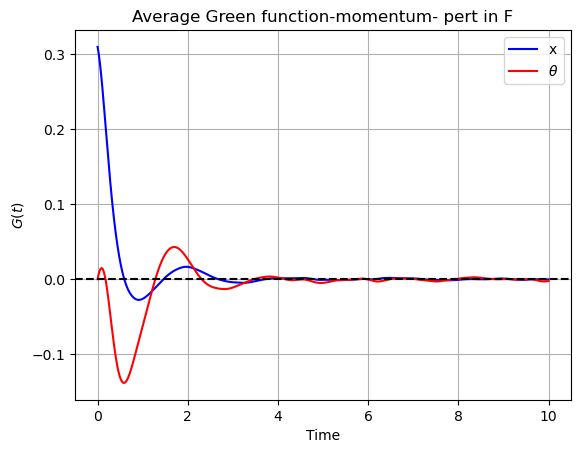

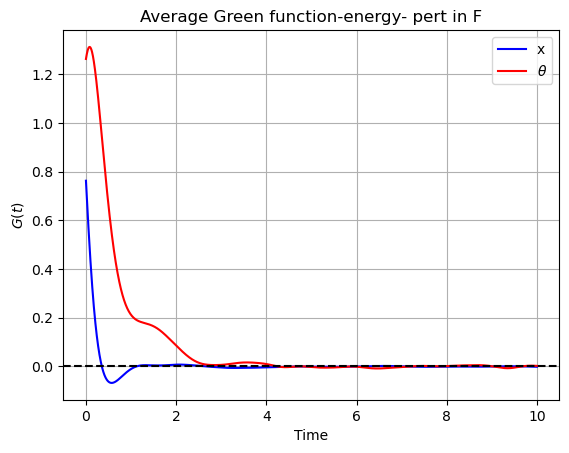

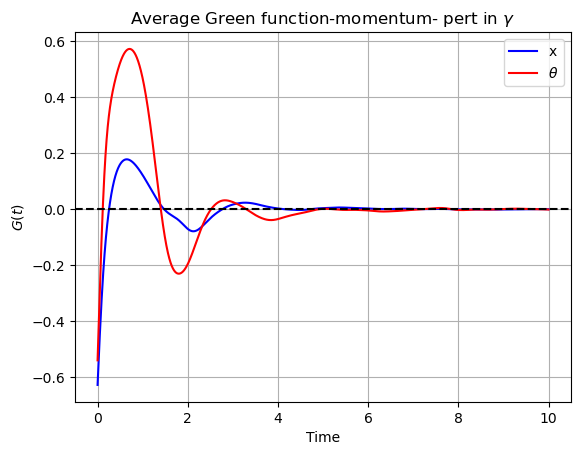

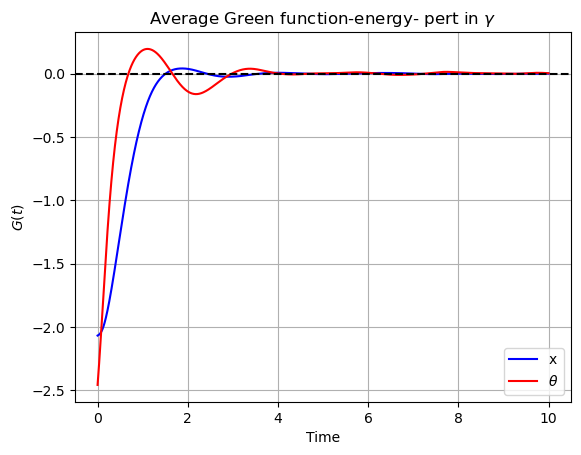

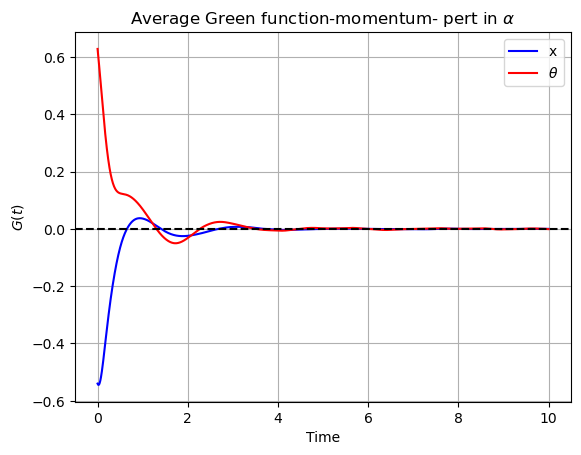

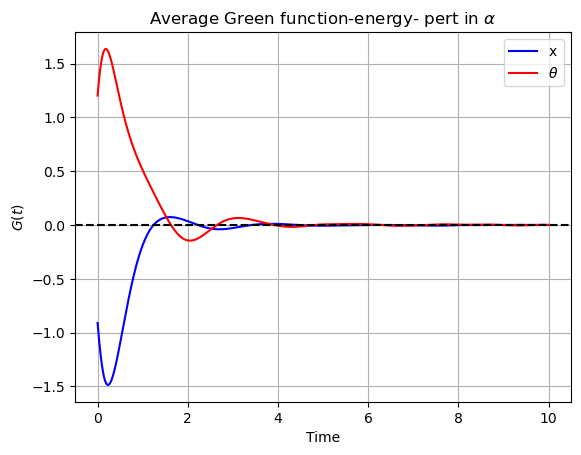

In [53]:
#Average of the green functions
G_mom_x_F =(G_mom_1x_F + G_mom_2x_F + G_mom_3x_F) / 3
G_mom_z_F =(G_mom_1z_F + G_mom_2z_F + G_mom_3z_F) / 3

G_energy_x_F = (G_energy_1x_F + G_energy_2x_F + G_energy_3x_F) /3
G_energy_z_F = (G_energy_1z_F + G_energy_2z_F + G_energy_3z_F) /3

G_mom_x_g =(G_mom_1x_g + G_mom_2x_g + G_mom_3x_g) / 3
G_mom_z_g =(G_mom_1z_g + G_mom_2z_g + G_mom_3z_g) / 3

G_energy_x_g = (G_energy_1x_g + G_energy_2x_g + G_energy_3x_g) /3
G_energy_z_g = (G_energy_1z_g + G_energy_2z_g + G_energy_3z_g) /3

G_mom_x_a =(G_mom_1x_a + G_mom_2x_a + G_mom_3x_a) / 3
G_mom_z_a =(G_mom_1z_a + G_mom_2z_a + G_mom_3z_a) / 3

G_energy_x_a = (G_energy_1x_a + G_energy_2x_a + G_energy_3x_a) /3
G_energy_z_a = (G_energy_1z_a + G_energy_2z_a + G_energy_3z_a) /3

time_relax = np.arange(0, 10, dt)

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_x_F, label='x', color = 'blue')
ax.plot(time_relax, G_mom_z_F, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title("Average Green function-momentum- pert in F")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(time_relax, G_energy_x_F, label='x', color = 'blue')
ax.plot(time_relax, G_energy_z_F, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title("Average Green function-energy- pert in F")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_x_g, label='x', color = 'blue')
ax.plot(time_relax, G_mom_z_g, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title("Average Green function-momentum- pert in $\gamma$")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(time_relax, G_energy_x_g, label='x', color = 'blue')
ax.plot(time_relax, G_energy_z_g, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title("Average Green function-energy- pert in $\gamma$")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()

fig, ax = plt.subplots()
ax.plot(time_relax, G_mom_x_a, label='x', color = 'blue')
ax.plot(time_relax, G_mom_z_a, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title(r"Average Green function-momentum- pert in $\alpha$")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(time_relax, G_energy_x_a, label='x', color = 'blue')
ax.plot(time_relax, G_energy_z_a, label='$\\theta$', color = 'red')
ax.set_xlabel("Time")
ax.set_ylabel(r"$G(t)$")
ax.set_title(r"Average Green function-energy- pert in $\alpha$")
ax.axhline(0, color='black', linestyle='--')
ax.legend()
ax.grid()

plt.show()